# PASO 1: Análisis Exploratorio de Datos (EDA)
## Predicción de Deserción Estudiantil
Dataset: UCI - Predict Students' Dropout and Academic Success

**Objetivo:** Explorar el dataset, entender distribuciones, correlaciones y detectar outliers.

In [30]:
# Instalación de librerías necesarias
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy -U
!pip install -q xgboost shap groq python-dotenv


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.1 Descargar el Dataset

In [32]:
# Descargar el dataset directamente desde UCI
url = "https://archive.ics.uci.edu/static/public/697/data.csv"

try:
    df = pd.read_csv(url)
    print(f"✅ Dataset descargado exitosamente")
    print(f"📊 Tamaño del dataset: {df.shape}")
except Exception as e:
    print(f"⚠️ Error descargando desde UCI. Intenta usar este enlace: {url}")
    print(f"Error: {e}")

✅ Dataset descargado exitosamente
📊 Tamaño del dataset: (4424, 37)


### 1.2 Resumen Estadístico Completo

In [33]:
# Información general del dataset
print("="*80)
print("RESUMEN GENERAL DEL DATASET")
print("="*80)
print(f"\n📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n🔍 Tipos de datos:")
print(df.dtypes)

print(f"\n⚠️ Valores nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No hay valores nulos")

print(f"\n📊 Estadísticas descriptivas:")
print(df.describe())

RESUMEN GENERAL DEL DATASET

📐 Dimensiones: 4424 filas × 37 columnas

🔍 Tipos de datos:
Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                    

In [34]:
# Información detallada de cada columna
print("\n" + "="*80)
print("INFORMACIÓN DETALLADA DE COLUMNAS")
print("="*80)
for col in df.columns:
    print(f"\n🔹 {col}")
    print(f"   Tipo: {df[col].dtype}")
    print(f"   Valores únicos: {df[col].nunique()}")
    if df[col].nunique() <= 10:
        print(f"   Valores: {df[col].unique()[:10]}")


INFORMACIÓN DETALLADA DE COLUMNAS

🔹 Marital Status
   Tipo: int64
   Valores únicos: 6
   Valores: [1 2 4 3 5 6]

🔹 Application mode
   Tipo: int64
   Valores únicos: 18

🔹 Application order
   Tipo: int64
   Valores únicos: 8
   Valores: [5 1 2 4 3 6 9 0]

🔹 Course
   Tipo: int64
   Valores únicos: 17

🔹 Daytime/evening attendance
   Tipo: int64
   Valores únicos: 2
   Valores: [1 0]

🔹 Previous qualification
   Tipo: int64
   Valores únicos: 17

🔹 Previous qualification (grade)
   Tipo: float64
   Valores únicos: 101

🔹 Nacionality
   Tipo: int64
   Valores únicos: 21

🔹 Mother's qualification
   Tipo: int64
   Valores únicos: 29

🔹 Father's qualification
   Tipo: int64
   Valores únicos: 34

🔹 Mother's occupation
   Tipo: int64
   Valores únicos: 32

🔹 Father's occupation
   Tipo: int64
   Valores únicos: 46

🔹 Admission grade
   Tipo: float64
   Valores únicos: 620

🔹 Displaced
   Tipo: int64
   Valores únicos: 2
   Valores: [1 0]

🔹 Educational special needs
   Tipo: int64
   Va

### 1.3 Análisis de la Variable Objetivo

In [35]:
# Identificar la columna Target
target_col = 'Target' if 'Target' in df.columns else df.columns[-1]
print(f"✅ Columna Target identificada: {target_col}")
print(f"\n📊 Distribución de clases:")
print(df[target_col].value_counts())
print(f"\n📈 Proporción (%)")
print(df[target_col].value_counts(normalize=True) * 100)

✅ Columna Target identificada: Target

📊 Distribución de clases:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

📈 Proporción (%)
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


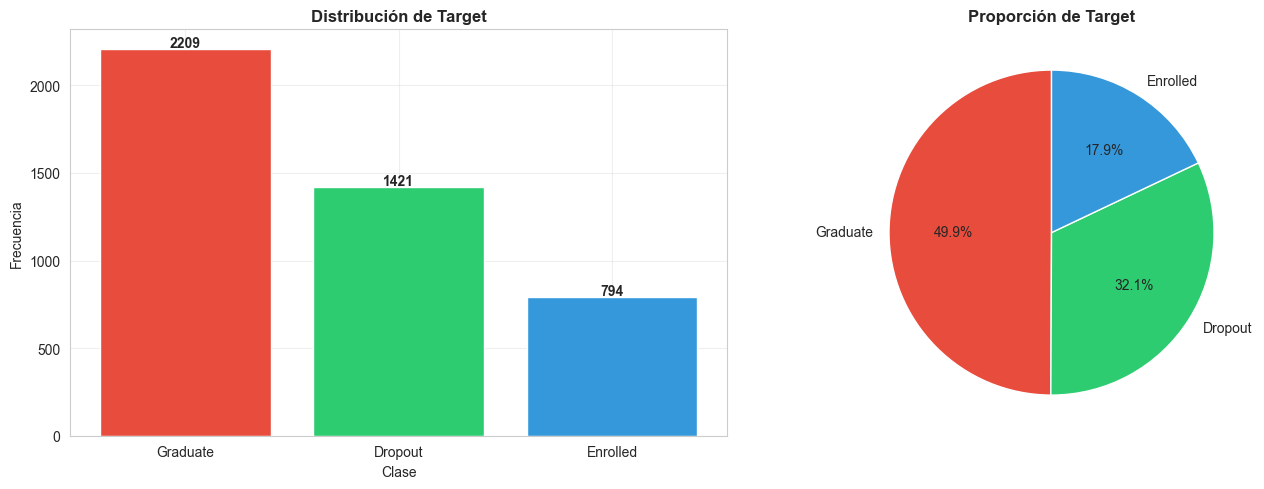

✅ Figura guardada: 01_target_distribution.png


In [36]:
# Gráfico de distribución del Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
target_counts = df[target_col].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db']
axes[0].bar(target_counts.index, target_counts.values, color=colors[:len(target_counts)])
axes[0].set_title(f'Distribución de {target_col}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)
# Añadir valores en barras
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Gráfico de pastel
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors[:len(target_counts)], startangle=90)
axes[1].set_title(f'Proporción de {target_col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 01_target_distribution.png")

### 1.4 Matriz de Correlación y Top Features

In [42]:
# Preparar datos numéricos para correlación
# PASO 1: Extraer solo columnas numéricas
df_numeric = df.select_dtypes(include=[np.number]).copy()

# PASO 2: Mapear el target a numérico PRIMERO
target_numeric_col = target_col + '_numeric'  # Crear columna temporal
if target_col in df.columns and target_col not in df_numeric.columns:
    # Target es categórico (string)
    target_mapping = {val: i for i, val in enumerate(sorted(df[target_col].unique()))}
    df_numeric[target_numeric_col] = df[target_col].map(target_mapping).astype(float)
    print(f"📊 Mapeo de Target: {target_mapping}")
    # Renombrar para uniformidad
    df_numeric.rename(columns={target_numeric_col: target_col}, inplace=True)
elif target_col in df.columns:
    # Target ya es numérico
    df_numeric[target_col] = df[target_col].astype(float)

# PASO 3: Asegurar que TODAS las columnas sean float (sin excepciones)
df_numeric = df_numeric.astype(float)

# PASO 4: Calcular correlación
correlacion = df_numeric.corr()
print(f"\n✅ Matriz de correlación calculada: {correlacion.shape}")
print(f"✅ Columnas numéricas: {len(df_numeric.columns)}")
print(f"✅ Target en matriz: {target_col in correlacion.columns}")

📊 Mapeo de Target: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}

✅ Matriz de correlación calculada: (37, 37)
✅ Columnas numéricas: 37
✅ Target en matriz: True


In [43]:
# Top 15 features más correlacionadas con Target
if target_col in correlacion.columns:
    corr_con_target = correlacion[target_col].abs().sort_values(ascending=False)
    print(f"\n📊 Top 15 features correlacionadas con {target_col}:")
    print(corr_con_target.head(16))  # 16 porque incluye el target mismo
    
    top_features = corr_con_target[1:16].index.tolist()  # Excluir el target
else:
    # Si no está en correlación, calcular manualmente
    print(f"⚠️ {target_col} no está. Calculando correlación con target...")
    # Mapear el target
    if df[target_col].dtype == 'object':
        target_numeric = pd.factorize(df[target_col])[0]
    else:
        target_numeric = df[target_col]
    
    # Correlacionar cada feature con el target
    correlaciones_target = {}
    for col in df_numeric.columns:
        corr_val = abs(np.corrcoef(df_numeric[col].fillna(df_numeric[col].mean()), target_numeric)[0, 1])
        correlaciones_target[col] = corr_val
    
    corr_con_target = pd.Series(correlaciones_target).sort_values(ascending=False)
    print(f"\n📊 Top 15 features correlacionadas con {target_col}:")
    print(corr_con_target.head(15))
    
    top_features = corr_con_target[:15].index.tolist()

print(f"\n✅ Top {len(top_features)} features definidos")


📊 Top 15 features correlacionadas con Target:
Target                                 1.000000
Curricular units 2nd sem (approved)    0.624157
Curricular units 2nd sem (grade)       0.566827
Curricular units 1st sem (approved)    0.529123
Curricular units 1st sem (grade)       0.485207
Tuition fees up to date                0.409827
Scholarship holder                     0.297595
Age at enrollment                      0.243438
Debtor                                 0.240999
Gender                                 0.229270
Application mode                       0.221747
Curricular units 2nd sem (enrolled)    0.175847
Curricular units 1st sem (enrolled)    0.155974
Admission grade                        0.120889
Displaced                              0.113986
Previous qualification (grade)         0.103764
Name: Target, dtype: float64

✅ Top 15 features definidos


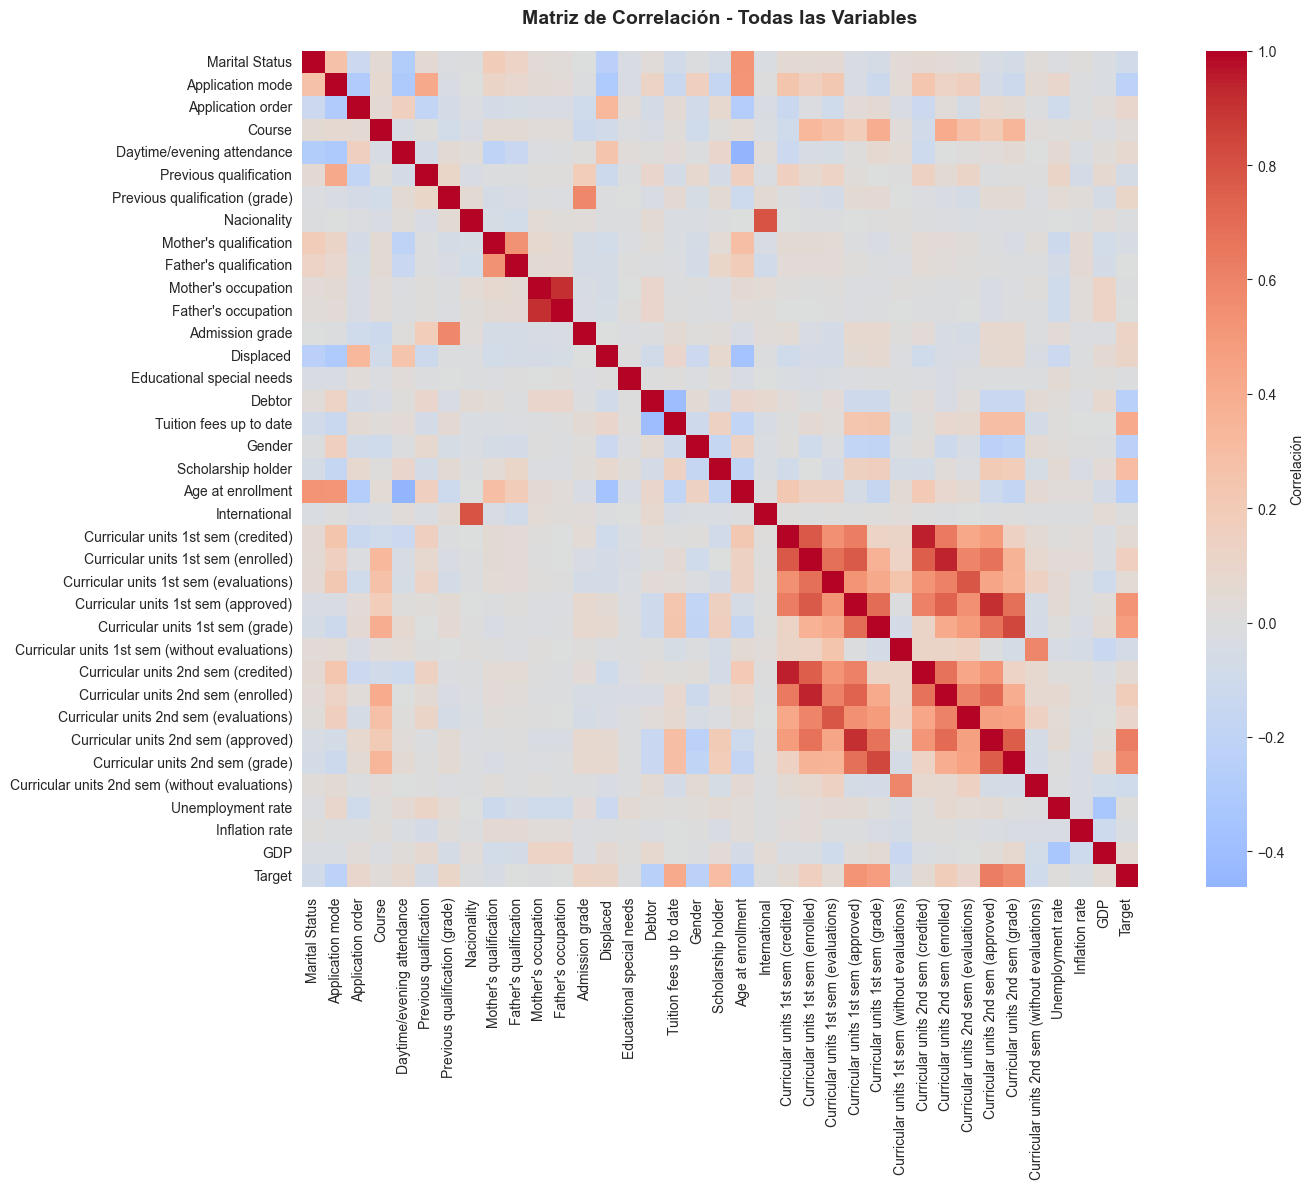

✅ Figura guardada: 02_correlation_matrix_full.png


In [44]:
# Heatmap de la matriz de correlación (todas las variables)
plt.figure(figsize=(16, 12))
sns.heatmap(correlacion, cmap='coolwarm', center=0, annot=False, 
            fmt='.2f', square=True, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación - Todas las Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/02_correlation_matrix_full.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 02_correlation_matrix_full.png")

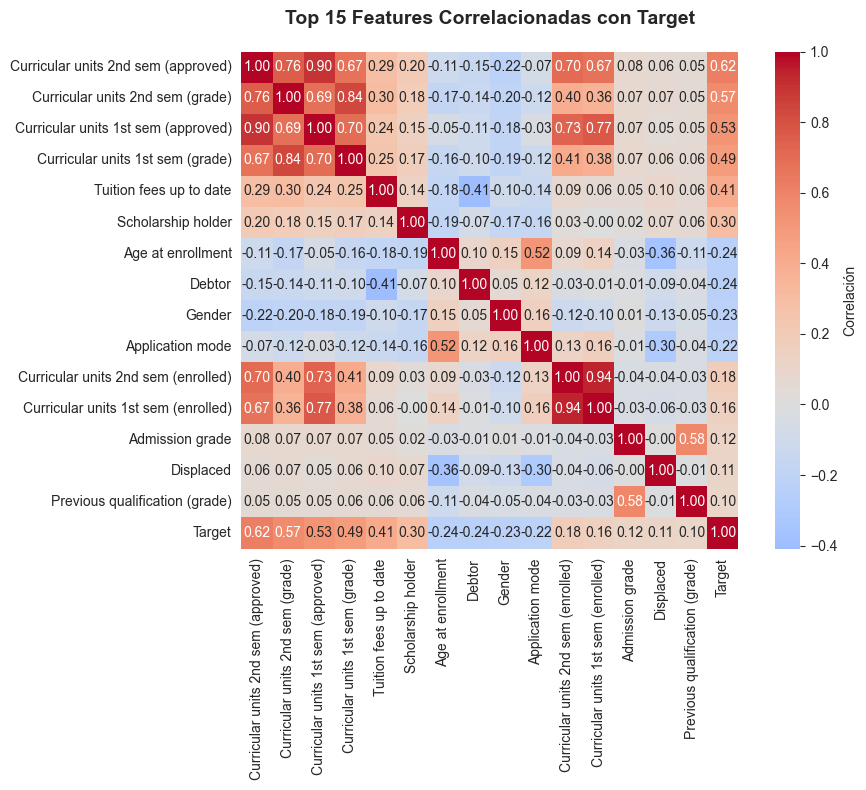

✅ Figura guardada: 03_correlation_top15.png


In [45]:
# Heatmap de Top 15 features
if len(top_features) > 0:
    corr_top = df_numeric[top_features + [target_col]].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_top, cmap='coolwarm', center=0, annot=True, 
                fmt='.2f', square=True, cbar_kws={'label': 'Correlación'})
    plt.title('Top 15 Features Correlacionadas con Target', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('../figures/03_correlation_top15.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Figura guardada: 03_correlation_top15.png")

### 1.5 Distribución de Top 6 Features Más Correlacionadas

✅ Top 6 Features seleccionadas: ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Tuition fees up to date', 'Scholarship holder']


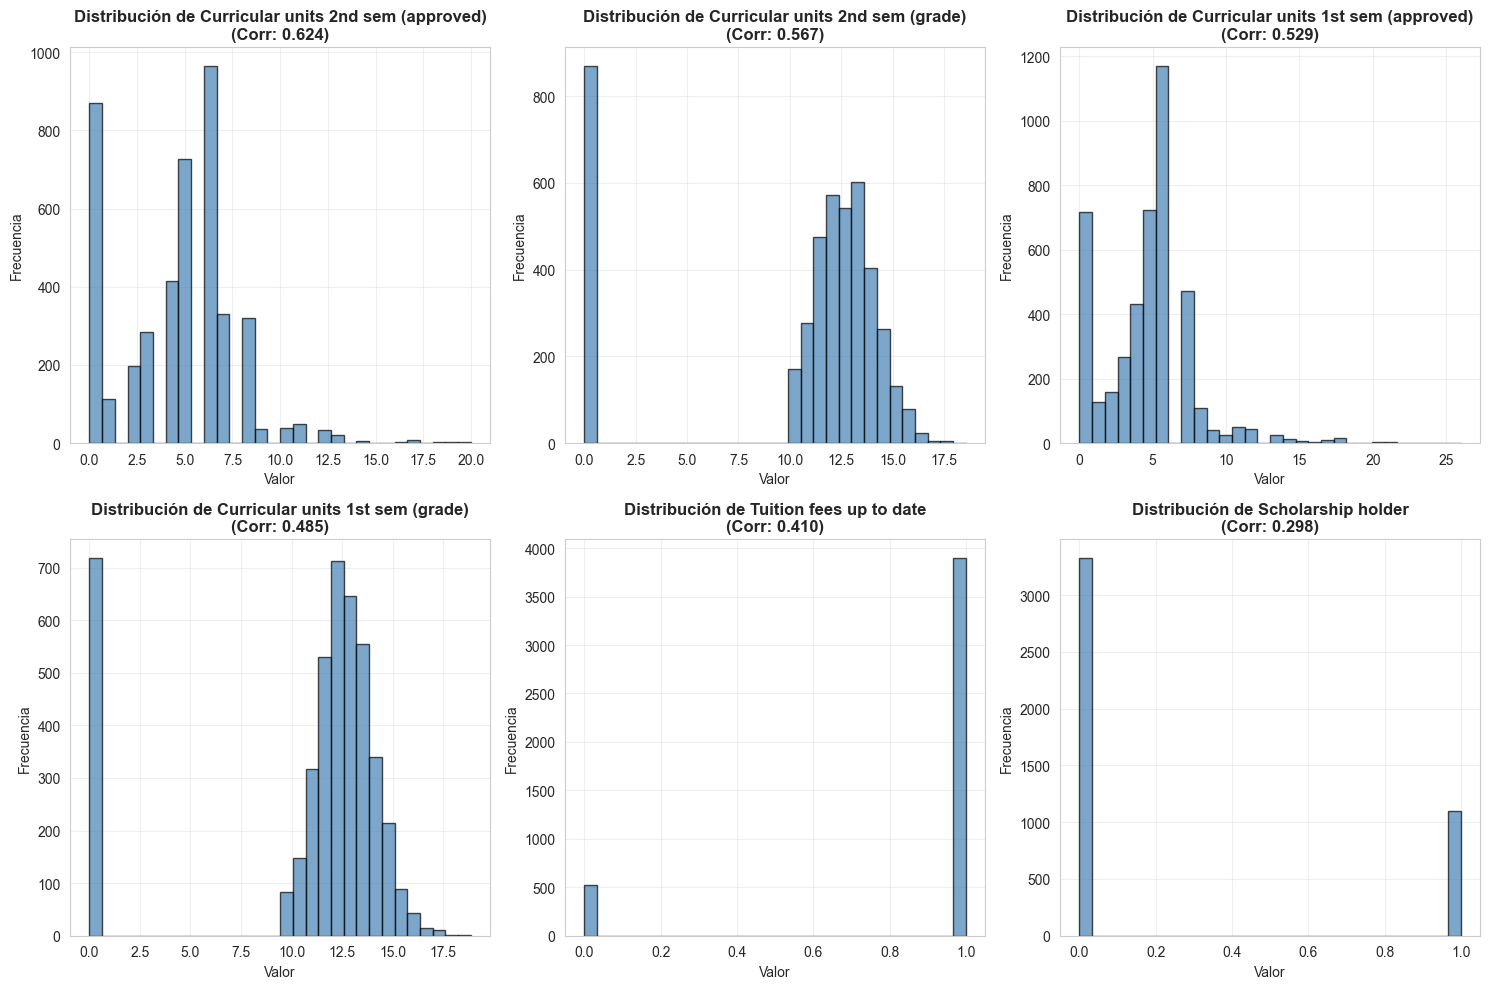

✅ Figura guardada: 04_top6_features_distribution.png


In [46]:
# Seleccionar top 6 features
top_6_features = top_features[:6] if len(top_features) >= 6 else top_features
print(f"✅ Top 6 Features seleccionadas: {top_6_features}")

# Crear gráficos de distribución
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_6_features):
    axes[idx].hist(df_numeric[feature], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribución de {feature}\n(Corr: {corr_con_target[feature]:.3f})', fontweight='bold')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/04_top6_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 04_top6_features_distribution.png")

### 1.6 Detección de Outliers (Boxplots)

In [47]:
# Calcular estadísticas de outliers
def detectar_outliers(data):
    """Detecta outliers usando IQR"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    return len(outliers), len(outliers) / len(data) * 100

print("\n📊 Análisis de Outliers (Método IQR):")
print("="*60)
for col in df_numeric.columns:
    if col == target_col:
        continue
    count, pct = detectar_outliers(df_numeric[col])
    if count > 0:
        print(f"{col}: {count} outliers ({pct:.2f}%)")


📊 Análisis de Outliers (Método IQR):
Marital Status: 505 outliers (11.42%)
Application order: 541 outliers (12.23%)
Course: 442 outliers (9.99%)
Daytime/evening attendance: 483 outliers (10.92%)
Previous qualification: 707 outliers (15.98%)
Previous qualification (grade): 179 outliers (4.05%)
Nacionality: 110 outliers (2.49%)
Mother's occupation: 182 outliers (4.11%)
Father's occupation: 177 outliers (4.00%)
Admission grade: 86 outliers (1.94%)
Educational special needs: 51 outliers (1.15%)
Debtor: 503 outliers (11.37%)
Tuition fees up to date: 528 outliers (11.93%)
Scholarship holder: 1099 outliers (24.84%)
Age at enrollment: 441 outliers (9.97%)
International: 110 outliers (2.49%)
Curricular units 1st sem (credited): 577 outliers (13.04%)
Curricular units 1st sem (enrolled): 424 outliers (9.58%)
Curricular units 1st sem (evaluations): 158 outliers (3.57%)
Curricular units 1st sem (approved): 180 outliers (4.07%)
Curricular units 1st sem (grade): 726 outliers (16.41%)
Curricular unit

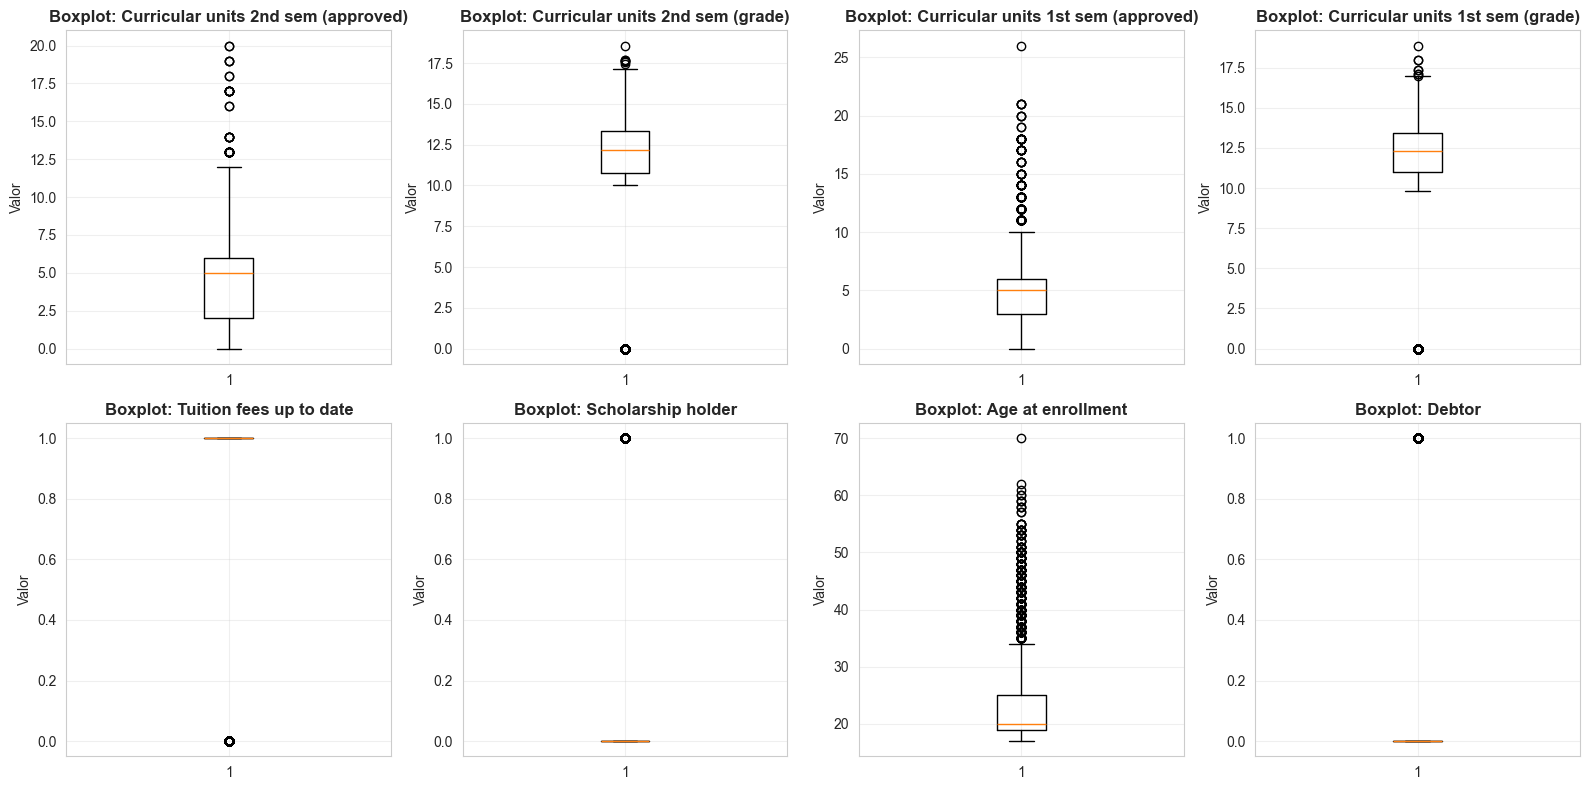

✅ Figura guardada: 05_boxplots_outliers.png


In [48]:
# Boxplots de top 8 features
top_8_features = top_features[:8] if len(top_features) >= 8 else top_features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(top_8_features):
    axes[idx].boxplot(df_numeric[feature], vert=True)
    axes[idx].set_title(f'Boxplot: {feature}', fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/05_boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 05_boxplots_outliers.png")

### 1.7 Análisis de Distribuciones por Clase (Target)

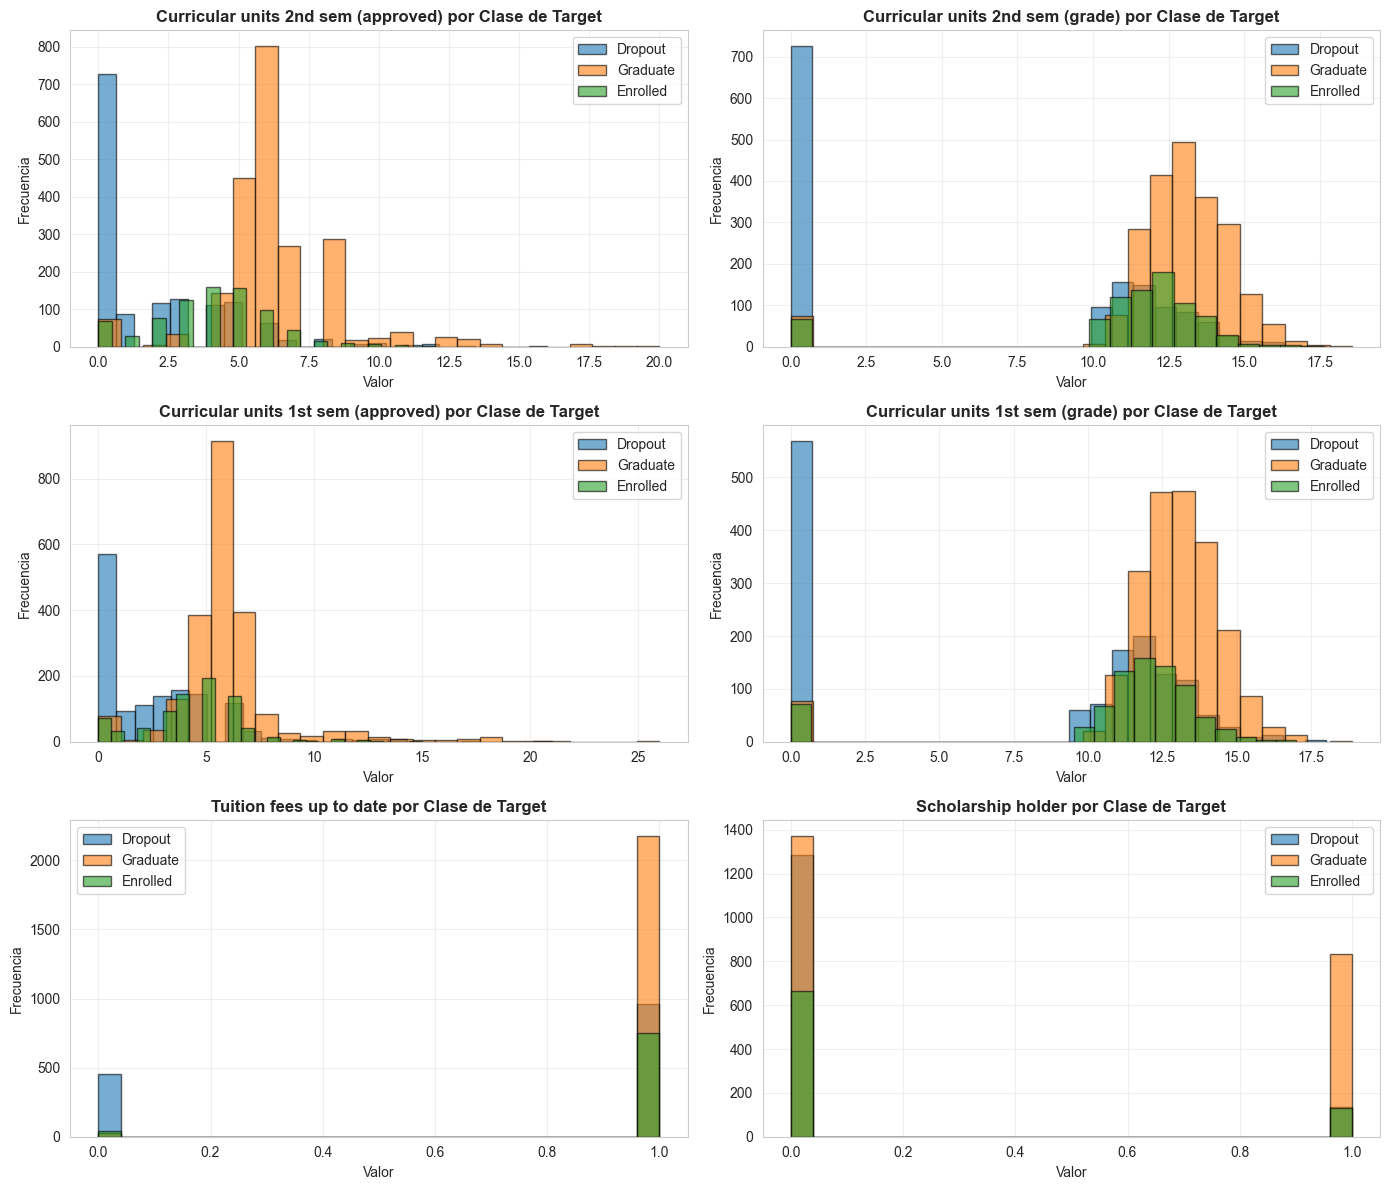

✅ Figura guardada: 06_features_by_class.png


In [49]:
# Distribuciones del Top 6 separadas por clase
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_6_features):
    for class_val in df[target_col].unique():
        mask = df[target_col] == class_val
        axes[idx].hist(df_numeric.loc[mask, feature], bins=25, alpha=0.6, label=class_val, edgecolor='black')
    
    axes[idx].set_title(f'{feature} por Clase de {target_col}', fontweight='bold')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/06_features_by_class.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 06_features_by_class.png")

### 1.8 Conclusiones del EDA

In [50]:
# Generar reporte de conclusiones
conclusiones = f"""
═══════════════════════════════════════════════════════════════════════════════
CONCLUSIONES DEL ANÁLISIS EXPLORATORIO (EDA)
═══════════════════════════════════════════════════════════════════════════════

📊 CARACTERÍSTICAS GENERALES DEL DATASET:
  • Tamaño: {df.shape[0]:,} muestras × {df.shape[1]} características
  • Valores nulos: {df.isnull().sum().sum()} (sin faltantes críticos)
  • Variables numéricas: {len(df_numeric.columns)}
  • Rango temporal: Estudiantes de múltiples cohortes y programas

🎯 VARIABLE OBJETIVO (Target):
"""

# Agregar detalles del target
for clase in df[target_col].unique():
    count = (df[target_col] == clase).sum()
    pct = count / len(df) * 100
    conclusiones += f"  • {clase}: {count:,} casos ({pct:.1f}%)\n"

conclusiones += f"""
  ⚠️ DESBALANCE DE CLASES: {'Sí (requiere atención en modelado)' if max(df[target_col].value_counts()) / len(df) > 0.6 else 'Moderado'}

🔗 FEATURES MÁS RELEVANTES (Top 6 por Correlación):
"""

for i, feature in enumerate(top_6_features, 1):
    corr_val = corr_con_target[feature]
    conclusiones += f"  {i}. {feature}: {corr_val:.3f}\n"

conclusiones += f"""
🚨 OUTLIERS DETECTADOS:
  • Método IQR (1.5 × IQR)
  • Features con outliers: {sum(1 for col in df_numeric.columns if col != target_col and detectar_outliers(df_numeric[col])[0] > 0)}
  • Acción: Mantener outliers (pueden ser casos reales de deserción) o usar escalado robusto

📈 DISTRIBUCIONES:
  • Distribuciones varían significativamente entre clases
  • Sugiere que los features tienen poder predictivo
  • Preparar datos: escalado con StandardScaler es recomendado

✅ RECOMENDACIONES PARA MODELADO:
  1. Usar StandardScaler para normalizar features
  2. Considerar técnicas de manejo de desbalance (si aplica)
  3. Validar con XGBoost que es robusto a outliers
  4. Usar top features para explicabilidad con SHAP
  5. División: 70% train, 15% val, 15% test (random_state=42)

═══════════════════════════════════════════════════════════════════════════════
"""

print(conclusiones)

# Guardar conclusiones en archivo
with open('../reports/01_EDA_conclusions.txt', 'w', encoding='utf-8') as f:
    f.write(conclusiones)

print("\n✅ Conclusiones guardadas en: 01_EDA_conclusions.txt")


═══════════════════════════════════════════════════════════════════════════════
CONCLUSIONES DEL ANÁLISIS EXPLORATORIO (EDA)
═══════════════════════════════════════════════════════════════════════════════

📊 CARACTERÍSTICAS GENERALES DEL DATASET:
  • Tamaño: 4,424 muestras × 37 características
  • Valores nulos: 0 (sin faltantes críticos)
  • Variables numéricas: 37
  • Rango temporal: Estudiantes de múltiples cohortes y programas

🎯 VARIABLE OBJETIVO (Target):
  • Dropout: 1,421 casos (32.1%)
  • Graduate: 2,209 casos (49.9%)
  • Enrolled: 794 casos (17.9%)

  ⚠️ DESBALANCE DE CLASES: Moderado

🔗 FEATURES MÁS RELEVANTES (Top 6 por Correlación):
  1. Curricular units 2nd sem (approved): 0.624
  2. Curricular units 2nd sem (grade): 0.567
  3. Curricular units 1st sem (approved): 0.529
  4. Curricular units 1st sem (grade): 0.485
  5. Tuition fees up to date: 0.410
  6. Scholarship holder: 0.298

🚨 OUTLIERS DETECTADOS:
  • Método IQR (1.5 × IQR)
  • Features con outliers: 28
  • Acción:

In [51]:
# Guardar el dataset procesado para el siguiente paso
df.to_csv('../data/processed/dataset_completo.csv', index=False)
print(f"✅ Dataset guardado: {df.shape}")
print(f"✅ EDA completado. Se han generado 5 figuras PNG en la carpeta 'figures/'")

✅ Dataset guardado: (4424, 37)
✅ EDA completado. Se han generado 5 figuras PNG en la carpeta 'figures/'
